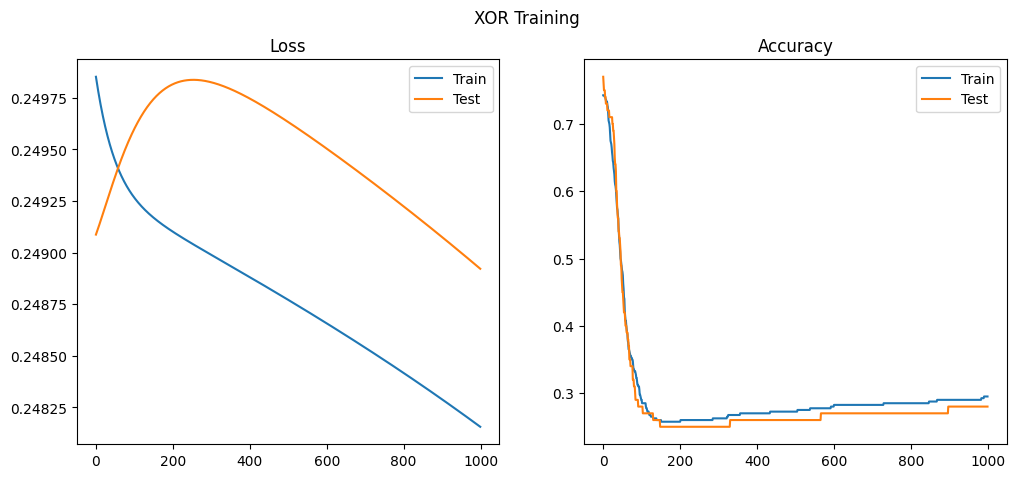

Final Train Loss: 0.24815583023107352
Final Test Loss: 0.2489217402860928
Final Train Acc: 0.295
Final Test Acc: 0.28


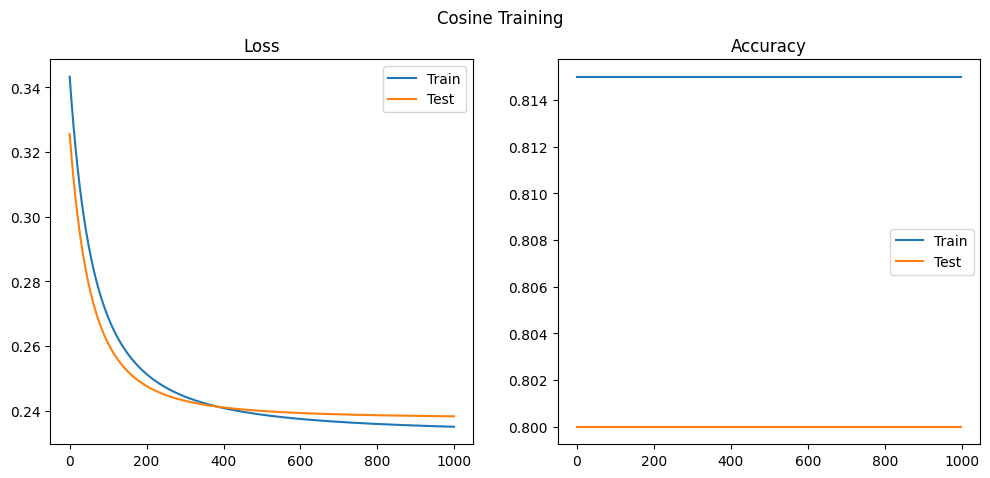

Final Train Loss: 0.23507455070016683
Final Test Loss: 0.23830698288545207
Final Train Acc: 0.815
Final Test Acc: 0.8


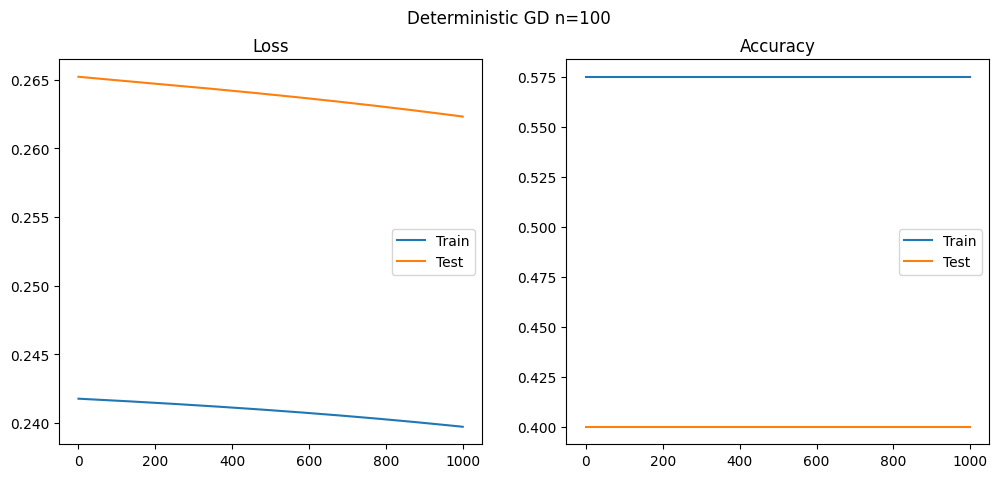

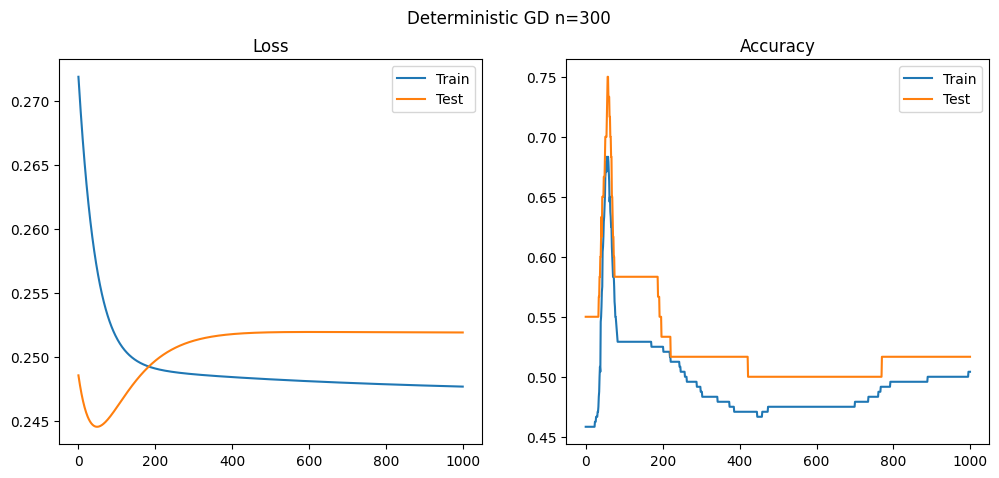

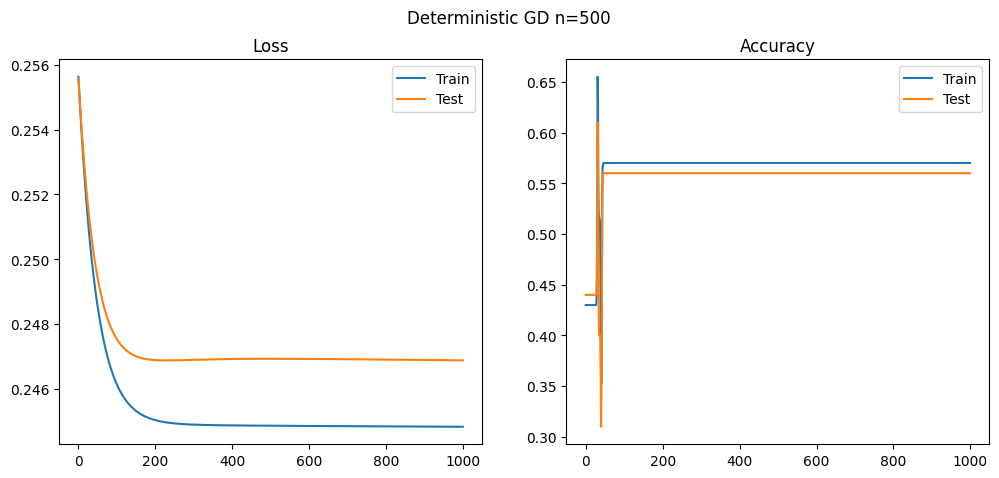

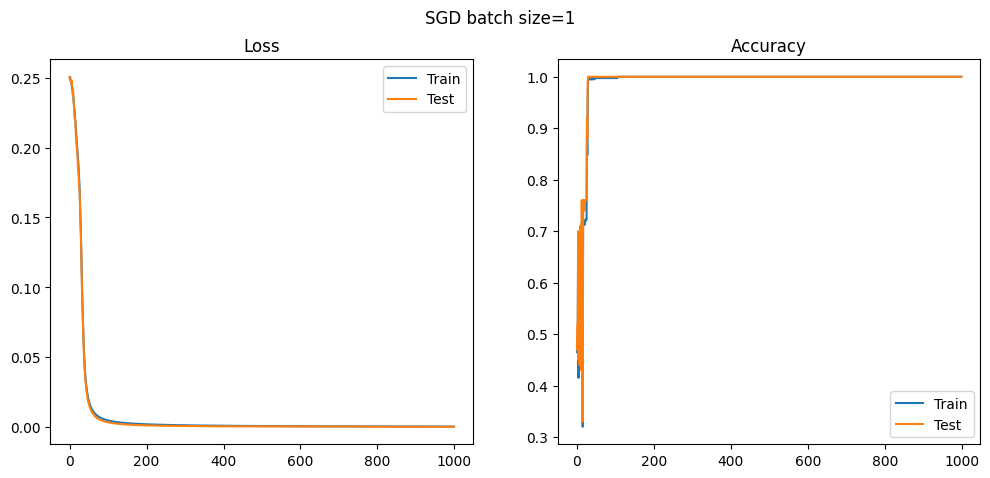

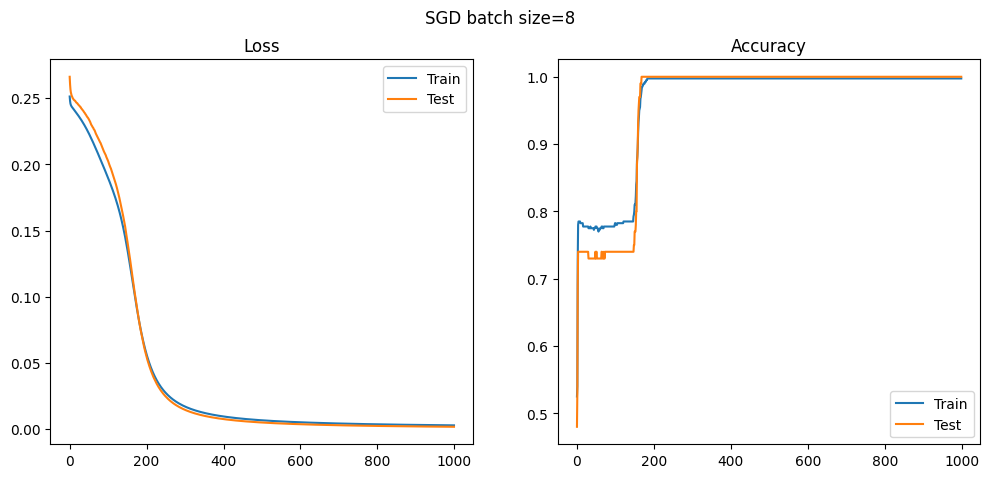

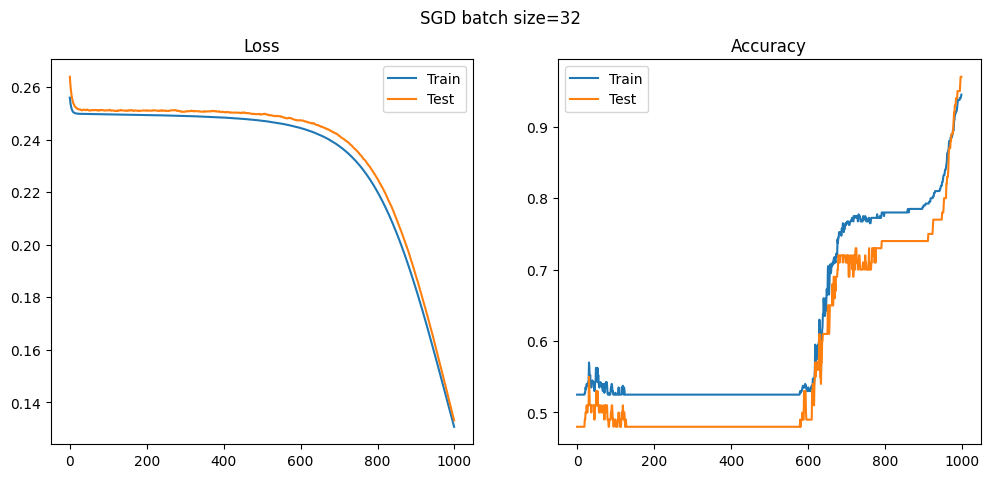

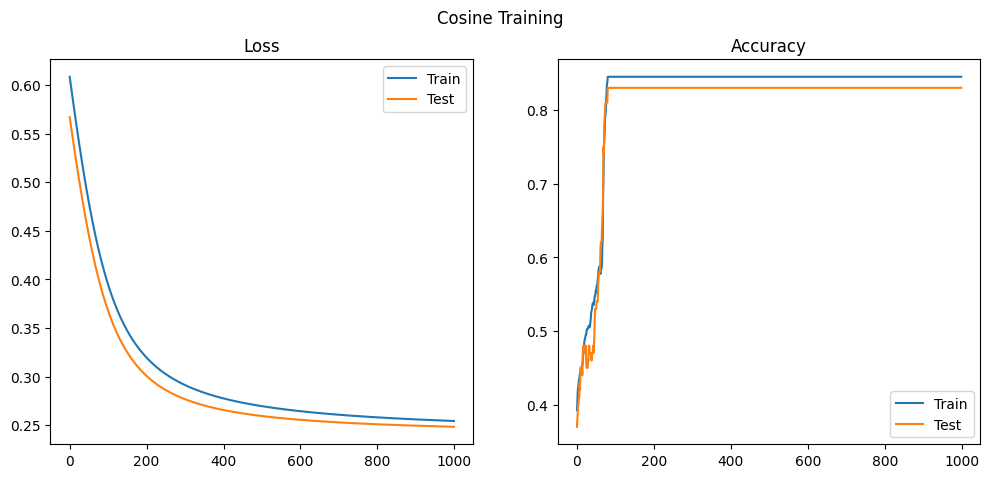

Final Train Loss: 0.2542736563631054
Final Test Loss: 0.24832892503316883
Final Train Accuracy: 0.845
Final Test Accuracy: 0.83


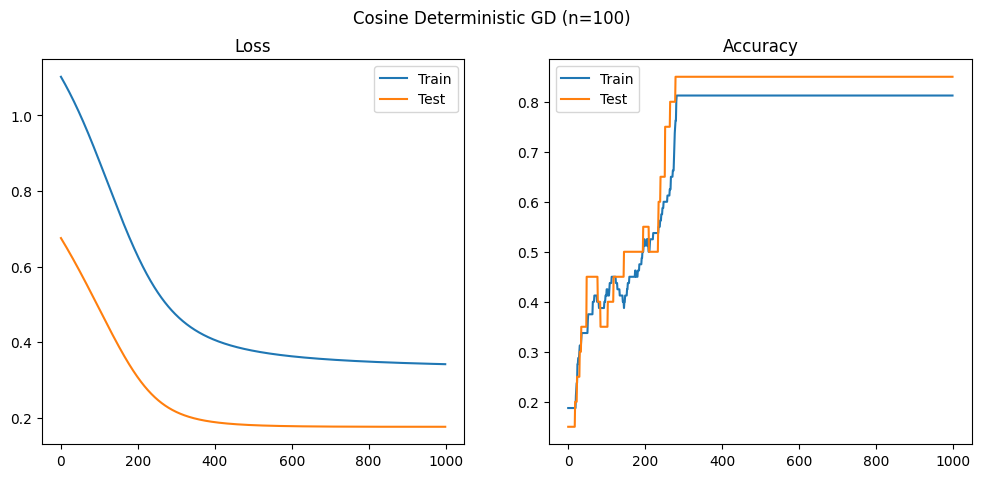

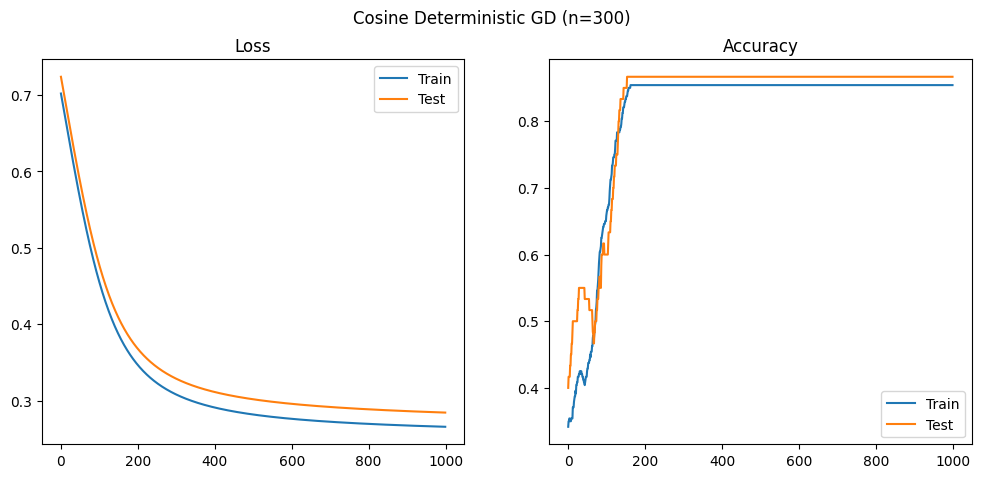

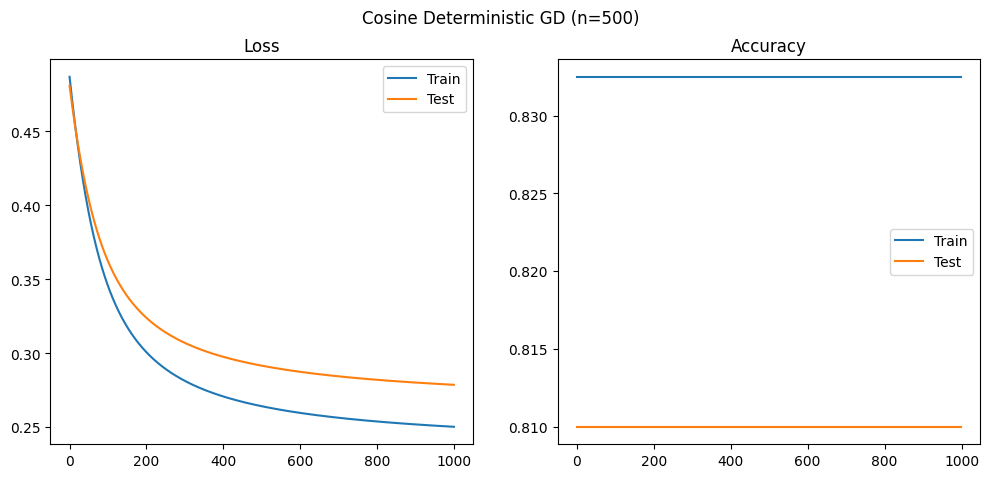

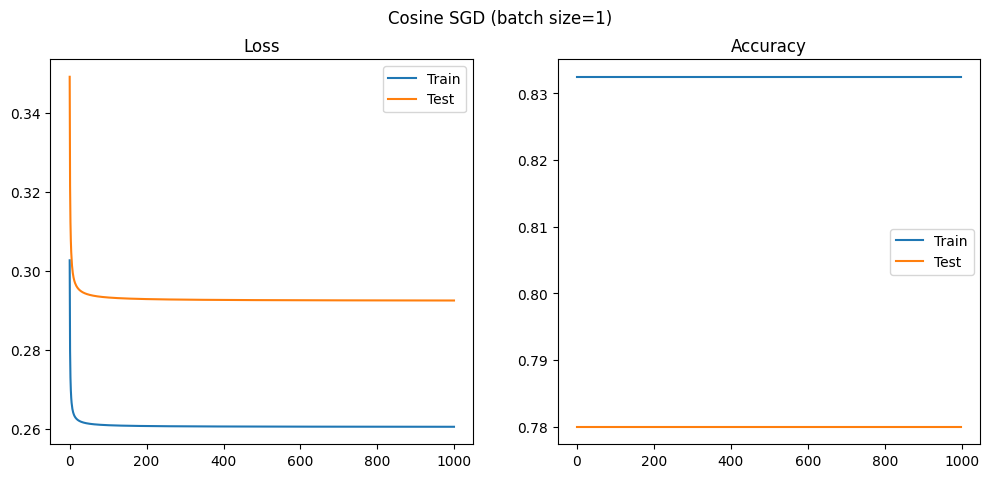

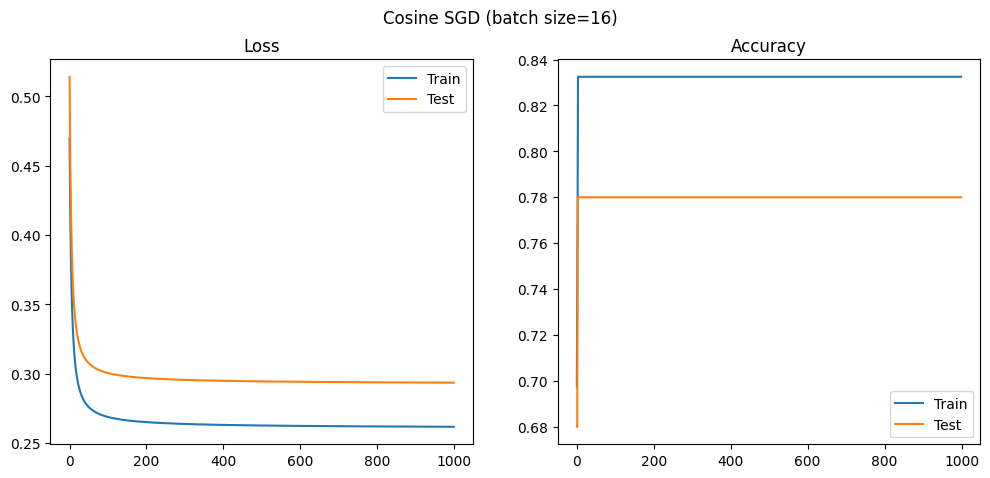

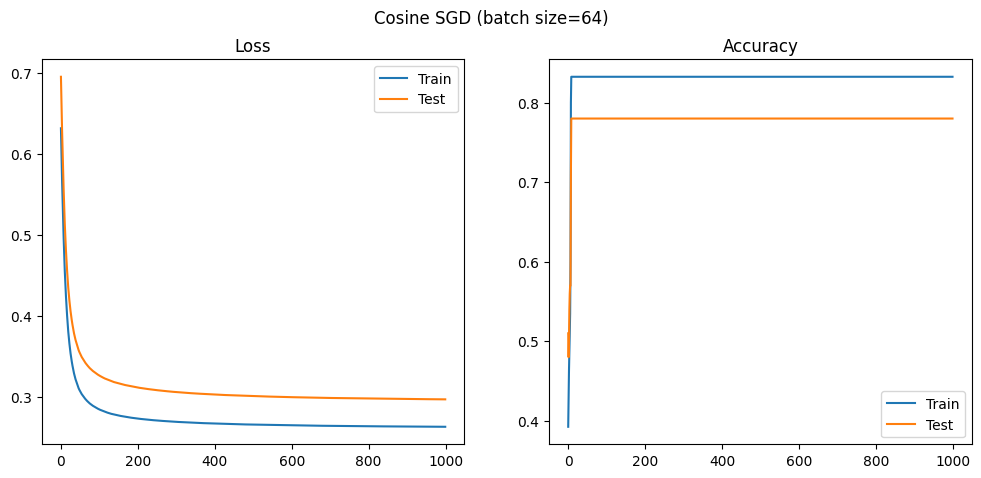

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# ----------------------------
# Activation Functions
# ----------------------------

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# ----------------------------
# Loss
# ----------------------------

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def accuracy(y_true, y_pred):
    y_pred_bin = (y_pred > 0.5).astype(int)
    y_true_bin = (y_true > 0.5).astype(int)
    return np.mean(y_pred_bin == y_true_bin)

# ----------------------------
# Dataset generation
# ----------------------------

def generate_xor_dataset(n=200, noise=0.1):

    base = np.array([
        [0,0],
        [0,1],
        [1,0],
        [1,1]
    ])

    labels = np.array([[0],[1],[1],[0]])

    X = []
    y = []

    for i in range(n):
        idx = np.random.randint(0,4)

        x = base[idx] + np.random.normal(0, noise, 2)
        X.append(x)

        y.append(labels[idx])

    return np.array(X), np.array(y)


def generate_cosine_dataset(n=200):

    X = np.random.uniform(-np.pi, np.pi, (n,2))

    y = (np.cos(X[:,0]) + np.cos(X[:,1]))/2
    y = y.reshape(-1,1)

    return X, y


# ----------------------------
# Train Test Split
# ----------------------------

def train_test_split(X,y,ratio=0.8):

    n = len(X)
    idx = np.random.permutation(n)

    train_size = int(n*ratio)

    train_idx = idx[:train_size]
    test_idx = idx[train_size:]

    return X[train_idx],X[test_idx],y[train_idx],y[test_idx]


# ----------------------------
# Neural Network
# ----------------------------

class NeuralNetwork:

    def __init__(self):

        self.W1 = np.random.randn(2,2)
        self.b1 = np.zeros((1,2))

        self.W2 = np.random.randn(2,1)
        self.b2 = np.zeros((1,1))

    def forward(self,X):

        self.z1 = X @ self.W1 + self.b1
        self.a1 = sigmoid(self.z1)

        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = sigmoid(self.z2)

        return self.a2

    def backward(self,X,y,lr):

        m = len(X)

        output = self.a2

        dZ2 = (output - y) * sigmoid_derivative(output)
        dW2 = self.a1.T @ dZ2 / m
        db2 = np.sum(dZ2, axis=0, keepdims=True)/m

        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * sigmoid_derivative(self.a1)

        dW1 = X.T @ dZ1 / m
        db1 = np.sum(dZ1,axis=0,keepdims=True)/m

        self.W1 -= lr*dW1
        self.b1 -= lr*db1
        self.W2 -= lr*dW2
        self.b2 -= lr*db2

# ----------------------------
# Training
# ----------------------------

def train_model(X_train,y_train,X_test,y_test,
                epochs=1000,
                lr=0.1,
                batch_size=None):

    net = NeuralNetwork()

    train_loss=[]
    test_loss=[]

    train_acc=[]
    test_acc=[]

    n=len(X_train)

    if batch_size is None:
        batch_size = n

    for epoch in range(epochs):

        perm=np.random.permutation(n)

        for i in range(0,n,batch_size):

            idx = perm[i:i+batch_size]

            Xb = X_train[idx]
            yb = y_train[idx]

            net.forward(Xb)
            net.backward(Xb,yb,lr)

        train_pred = net.forward(X_train)
        test_pred = net.forward(X_test)

        train_loss.append(mse(y_train,train_pred))
        test_loss.append(mse(y_test,test_pred))

        train_acc.append(accuracy(y_train,train_pred))
        test_acc.append(accuracy(y_test,test_pred))

    return net,train_loss,test_loss,train_acc,test_acc


# ----------------------------
# Plotting
# ----------------------------

def plot_results(train_loss,test_loss,train_acc,test_acc,title):

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(train_loss,label="Train")
    plt.plot(test_loss,label="Test")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(train_acc,label="Train")
    plt.plot(test_acc,label="Test")
    plt.title("Accuracy")
    plt.legend()

    plt.suptitle(title)
    plt.show()


# ----------------------------
# XOR Experiment
# ----------------------------

X,y = generate_xor_dataset(500)

X_train,X_test,y_train,y_test = train_test_split(X,y)

net,tl,vl,ta,va = train_model(X_train,y_train,X_test,y_test)

plot_results(tl,vl,ta,va,"XOR Training")

print("Final Train Loss:",tl[-1])
print("Final Test Loss:",vl[-1])
print("Final Train Acc:",ta[-1])
print("Final Test Acc:",va[-1])


# ----------------------------
# Cosine Experiment
# ----------------------------

X,y = generate_cosine_dataset(500)

X_train,X_test,y_train,y_test = train_test_split(X,y)

net,tl,vl,ta,va = train_model(X_train,y_train,X_test,y_test)

plot_results(tl,vl,ta,va,"Cosine Training")

print("Final Train Loss:",tl[-1])
print("Final Test Loss:",vl[-1])
print("Final Train Acc:",ta[-1])
print("Final Test Acc:",va[-1])


# ----------------------------
# Deterministic GD experiment
# ----------------------------

for n in [100,300,500]:

    X,y = generate_xor_dataset(n)

    X_train,X_test,y_train,y_test = train_test_split(X,y)

    net,tl,vl,ta,va = train_model(X_train,y_train,X_test,y_test)

    plot_results(tl,vl,ta,va,f"Deterministic GD n={n}")


# ----------------------------
# SGD experiment
# ----------------------------

batch_sizes=[1,8,32]

X,y = generate_xor_dataset(500)

X_train,X_test,y_train,y_test = train_test_split(X,y)

for m in batch_sizes:

    net,tl,vl,ta,va = train_model(
        X_train,y_train,
        X_test,y_test,
        batch_size=m
    )

    plot_results(tl,vl,ta,va,f"SGD batch size={m}")

def generate_cosine_dataset(n=200):

    X = np.random.uniform(-np.pi, np.pi, (n,2))

    y = (np.cos(X[:,0]) + np.cos(X[:,1])) / 2
    y = y.reshape(-1,1)

    return X, y
# ----------------------------
# Cosine Function Training
# ----------------------------

X, y = generate_cosine_dataset(500)

X_train, X_test, y_train, y_test = train_test_split(X, y)

net, train_loss, test_loss, train_acc, test_acc = train_model(
    X_train, y_train, X_test, y_test,
    epochs=1000,
    lr=0.05
)

plot_results(train_loss, test_loss, train_acc, test_acc,
             "Cosine Training")

print("Final Train Loss:", train_loss[-1])
print("Final Test Loss:", test_loss[-1])
print("Final Train Accuracy:", train_acc[-1])
print("Final Test Accuracy:", test_acc[-1])

# ----------------------------
# Deterministic GD for Cosine
# ----------------------------

sample_sizes = [100, 300, 500]

for n in sample_sizes:

    X, y = generate_cosine_dataset(n)

    X_train, X_test, y_train, y_test = train_test_split(X, y)

    net, train_loss, test_loss, train_acc, test_acc = train_model(
        X_train, y_train, X_test, y_test,
        epochs=1000,
        lr=0.05
    )

    plot_results(train_loss, test_loss, train_acc, test_acc,
                 f"Cosine Deterministic GD (n={n})")

# ----------------------------
# SGD for Cosine
# ----------------------------

batch_sizes = [1, 16, 64]

X, y = generate_cosine_dataset(500)

X_train, X_test, y_train, y_test = train_test_split(X, y)

for m in batch_sizes:

    net, train_loss, test_loss, train_acc, test_acc = train_model(
        X_train, y_train, X_test, y_test,
        epochs=1000,
        lr=0.05,
        batch_size=m
    )

    plot_results(train_loss, test_loss, train_acc, test_acc,
                 f"Cosine SGD (batch size={m})")

